## 11 — IF Staining: Marker Quantification Pre/Post Resiquimod

**Purpose:** Plot mean immunofluorescence intensity (Mean Gray Value / MFI) for epidermal markers S100A8/A9, KRT16, SERPINB4, and CD74 across treated (Week 0 vs. Week 8) and untreated (Week 0 vs. Week 24) lesional skin, by sample and clinical response/regression status.

**Inputs:**
- `_data/IF_staining/IF_Stain_Raw_data_from_Prism_SERPIN_Added.xlsx` — per-image IF quantification, one sheet per marker (`S100A8_9`, `KRT16`, `SERPINB4`, `CD74`)

**Outputs:**
- `_figures/IF_stains/IF_<marker>.pdf` — bar plot (mean ± SEM) per marker


# Setup

In [1]:
set.seed(1)
source('./utils.R')
library(readxl)

Load the raw IF data. Each sheet in the workbook corresponds to one marker and is in long format: one row per image/replicate, with `Sample_Old` (patient/sample label), `TimePt`, `Condition` (`LesTx` = treated lesion, `LesUntx` = untreated lesion), `Response` (responder/regressor status), and the measured `Value` (Mean Gray Value).

In [2]:
xlsx_path = '../_data/IF_staining/IF_Stain_Raw_data_from_Prism_SERPIN_Added.xlsx'
markers = c('S100A8_9', 'KRT16', 'SERPINB4', 'CD74')

marker_titles = c(
    'S100A8_9' = 'S100A8/A9 Epidermal',
    'KRT16'    = 'KRT16 Epidermal',
    'SERPINB4' = 'SERPINB4 Epidermal',
    'CD74'     = 'CD74 Epidermal'
)

raw_data = lapply(markers, function(m) read_excel(xlsx_path, sheet = m))
names(raw_data) = markers

# Format data for plotting

In [25]:
# Sample labels annotated with clinical response/regression status, as in the
# original Prism plots (K16_Prism.png, S100_Prism.png). DF010 appears in both the
# treated cohort (responder) and the untreated cohort (regressed), so samples are
# keyed by Sample_Old + Condition to disambiguate.
sample_annot = c(
    '5661-002_LesTx' = 'P1 LesTx (R)',
    'DF010_LesTx'    = 'P5 LesTx (R)',
    'UP003_LesTx'    = 'P3 LesTx (NR)',
    'UP010_LesTx'    = 'P2 LesTx (NR)',
    'DF010_LesUntx'  = 'P5 LesUntx (R)',
    'UP005_LesUntx'  = 'P11 LesUntx (R)',
    'UP013_LesUntx'  = 'P4 LesUntx (NR)'
)

sample_order = c('P1 LesTx (R)', 'P5 LesTx (R)', 'P3 LesTx (NR)', 'P2 LesTx (NR)',
                  'P5 LesUntx (R)', 'P11 LesUntx (R)', 'P4 LesUntx (NR)')

group_colors = c(
    'Week 0 Pre Resiquimod Treated'  = '#EE4035',
    'Week 8 Post Resiquimod Treated' = '#F3A950',
    'Week 0 Untreated'               = '#1C1CE0',
    'Week 24 Untreated'              = '#A452D6'
)
group_order = names(group_colors)


In [26]:
format_marker_data = function(df) {
    # Normalize inconsistent TimePt spacing/labels (e.g. "Week0" vs "Week 0")
    df$TimePt = trimws(gsub('Week24', 'Week 24', gsub('Week8', 'Week 8', gsub('Week0', 'Week 0', df$TimePt))))

    df$Group = NA
    df$Group[df$Condition == 'LesTx'   & df$TimePt == 'Week 0']  = 'Week 0 Pre Resiquimod Treated'
    df$Group[df$Condition == 'LesTx'   & df$TimePt == 'Week 8']  = 'Week 8 Post Resiquimod Treated'
    df$Group[df$Condition == 'LesUntx' & df$TimePt == 'Week 0']  = 'Week 0 Untreated'
    df$Group[df$Condition == 'LesUntx' & df$TimePt == 'Week 24'] = 'Week 24 Untreated'
    df$Group = factor(df$Group, levels = group_order)

    df$SampleKey = paste(df$Sample_Old, df$Condition, sep = '_')
    df$SampleLabel = factor(sample_annot[df$SampleKey], levels = sample_order)

    df
}

data_formatted = lapply(raw_data, format_marker_data)


# Plot each marker

In [78]:
plot_marker = function(df, marker) {
    summary_df = df %>%
        group_by(SampleLabel, Group) %>%
        summarise(mean = mean(Value), sem = sd(Value) / sqrt(n()), .groups = 'drop') %>%
        droplevels()

    ggplot(summary_df, aes(x = SampleLabel, y = mean, fill = Group)) +
        geom_col(position = position_dodge2(width = 0.9, preserve = 'single'),
                 width = 0.8, color = 'black', linewidth = 0.3) +
        geom_errorbar(aes(ymin = mean - sem, ymax = mean + sem),
                      position = position_dodge2(width = 0.1, padding = 0.6, preserve = 'single'),
                      width = 0.8) +
        scale_fill_manual(values = group_colors, drop = FALSE) +
        labs(x = NULL, y = 'Mean Gray Value (MFI)', fill = NULL,
             title = paste0(marker_titles[[marker]])) +
        theme_classic(base_size = 15) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1),
              plot.title = element_text(face = 'bold', size = 13))
}


In [79]:
dir.create('../_figures/IF_stains', showWarnings = FALSE)

fig.size(5, 8)
plots = list()
for (marker in markers) {
    p = plot_marker(data_formatted[[marker]], marker)
    plots[[marker]] = p

    pdf(paste0('../_figures/IF_stains/IF_', marker, '.pdf'), width = 8, height = 5)
    print(p)
    dev.off()
}


## S100A8/A9

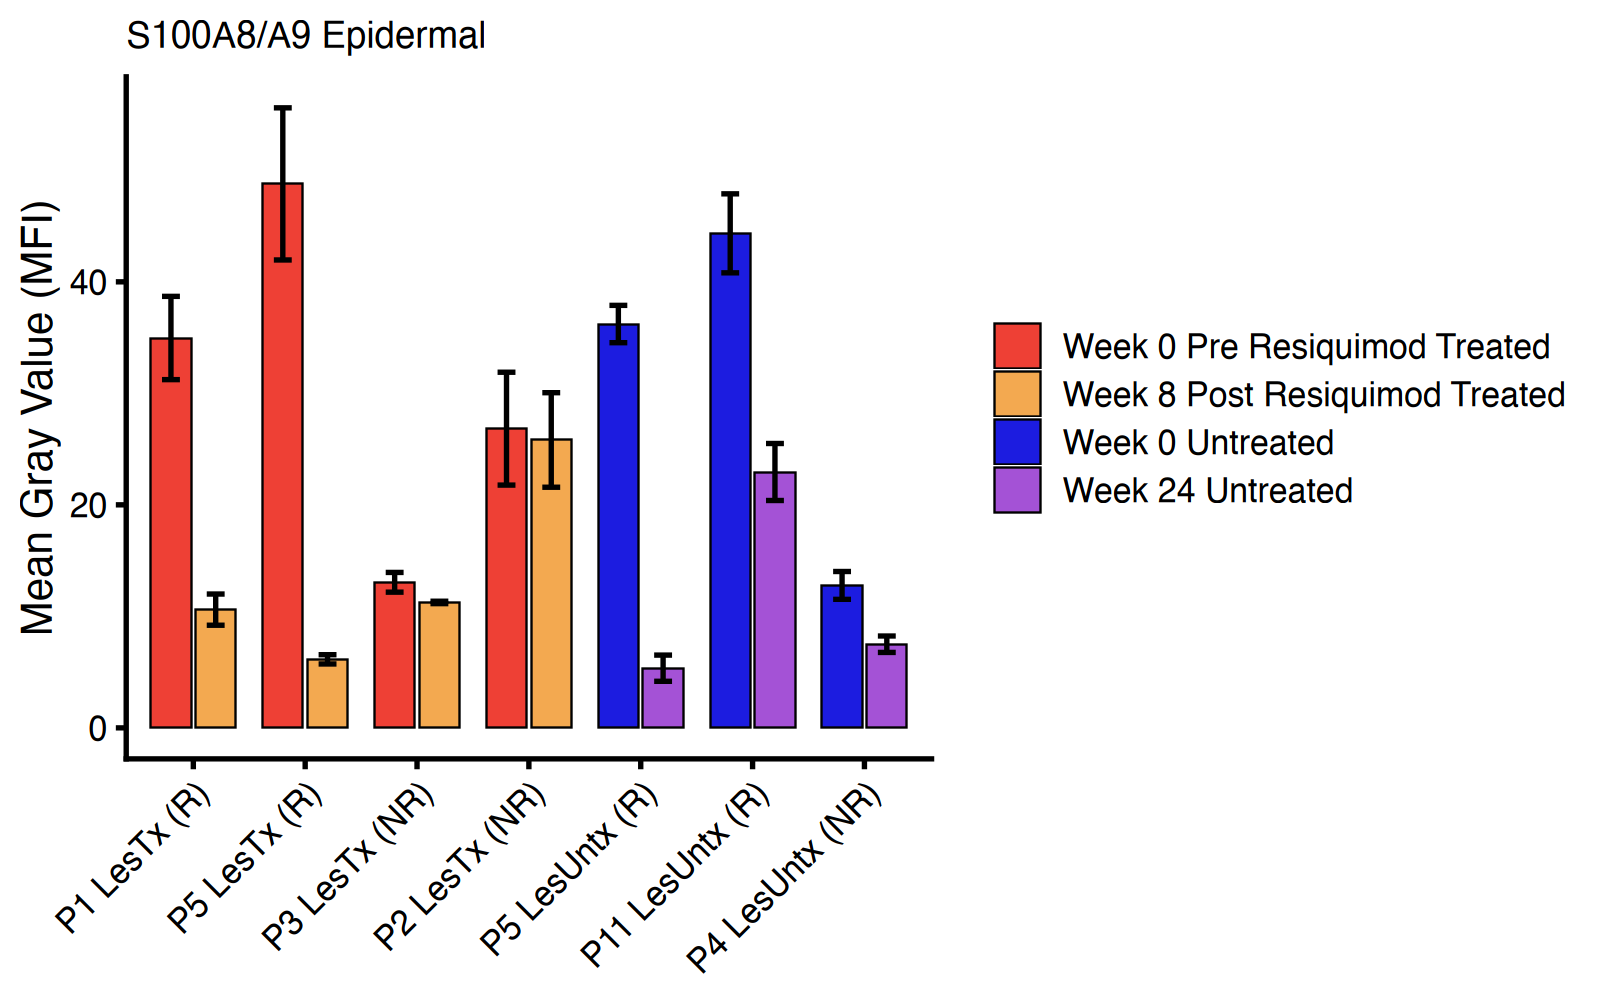

In [80]:
plots[['S100A8_9']]

## KRT16

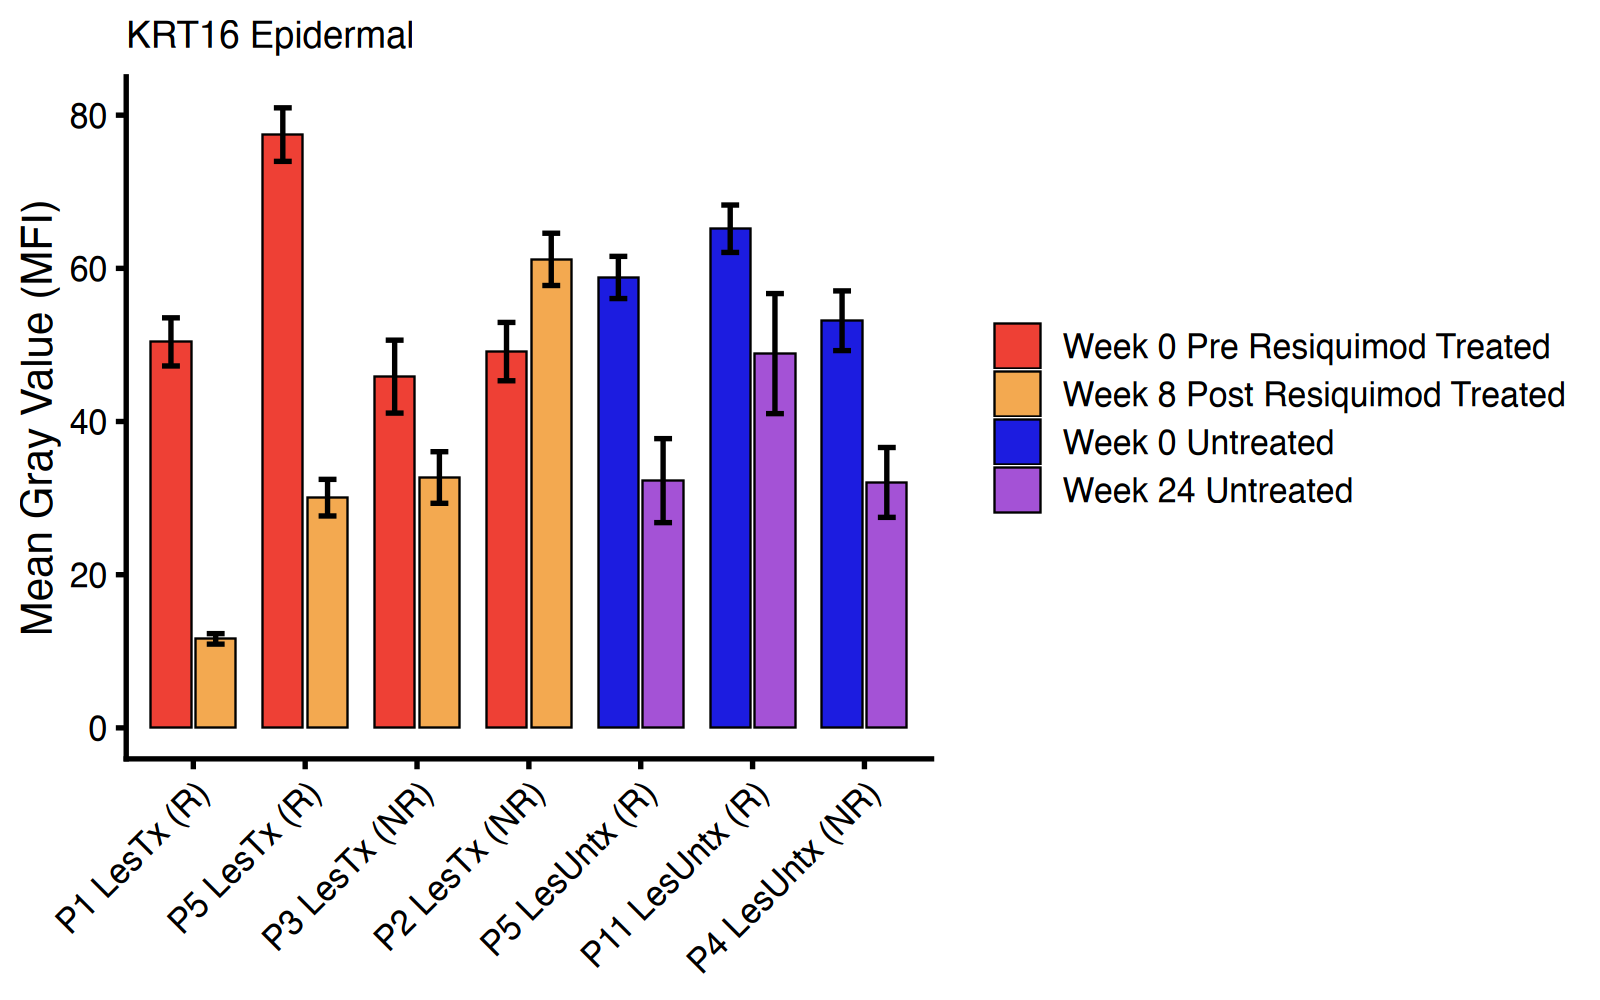

In [81]:
plots[['KRT16']]

## SERPINB4

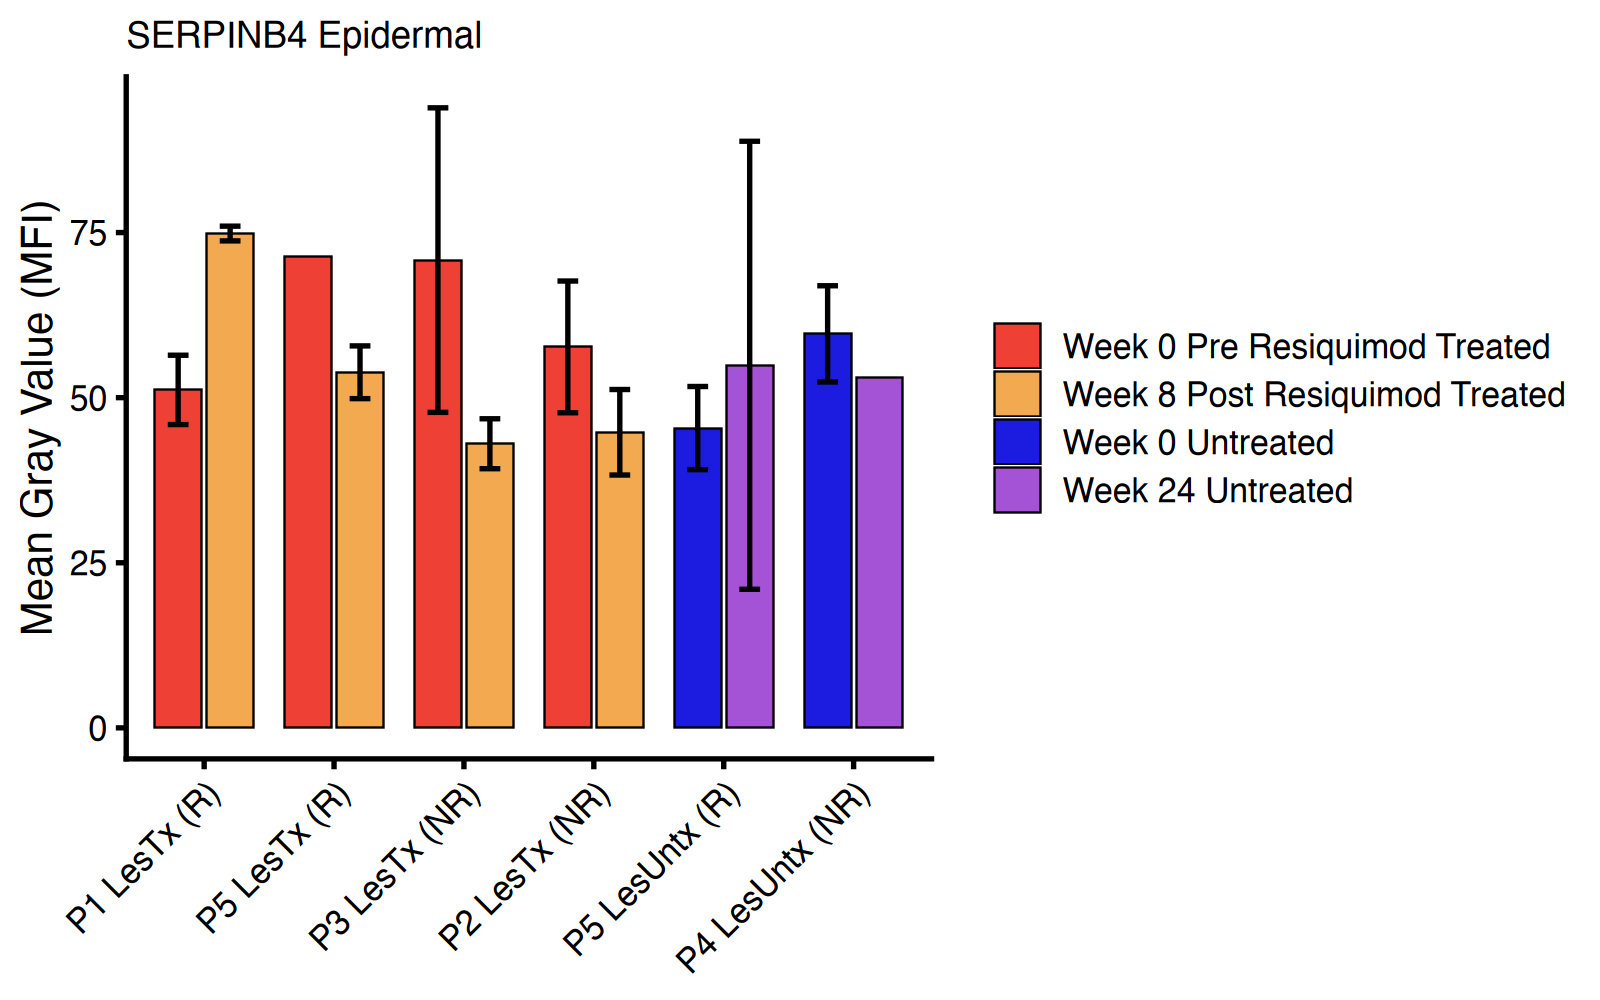

In [82]:
plots[['SERPINB4']]

## CD74

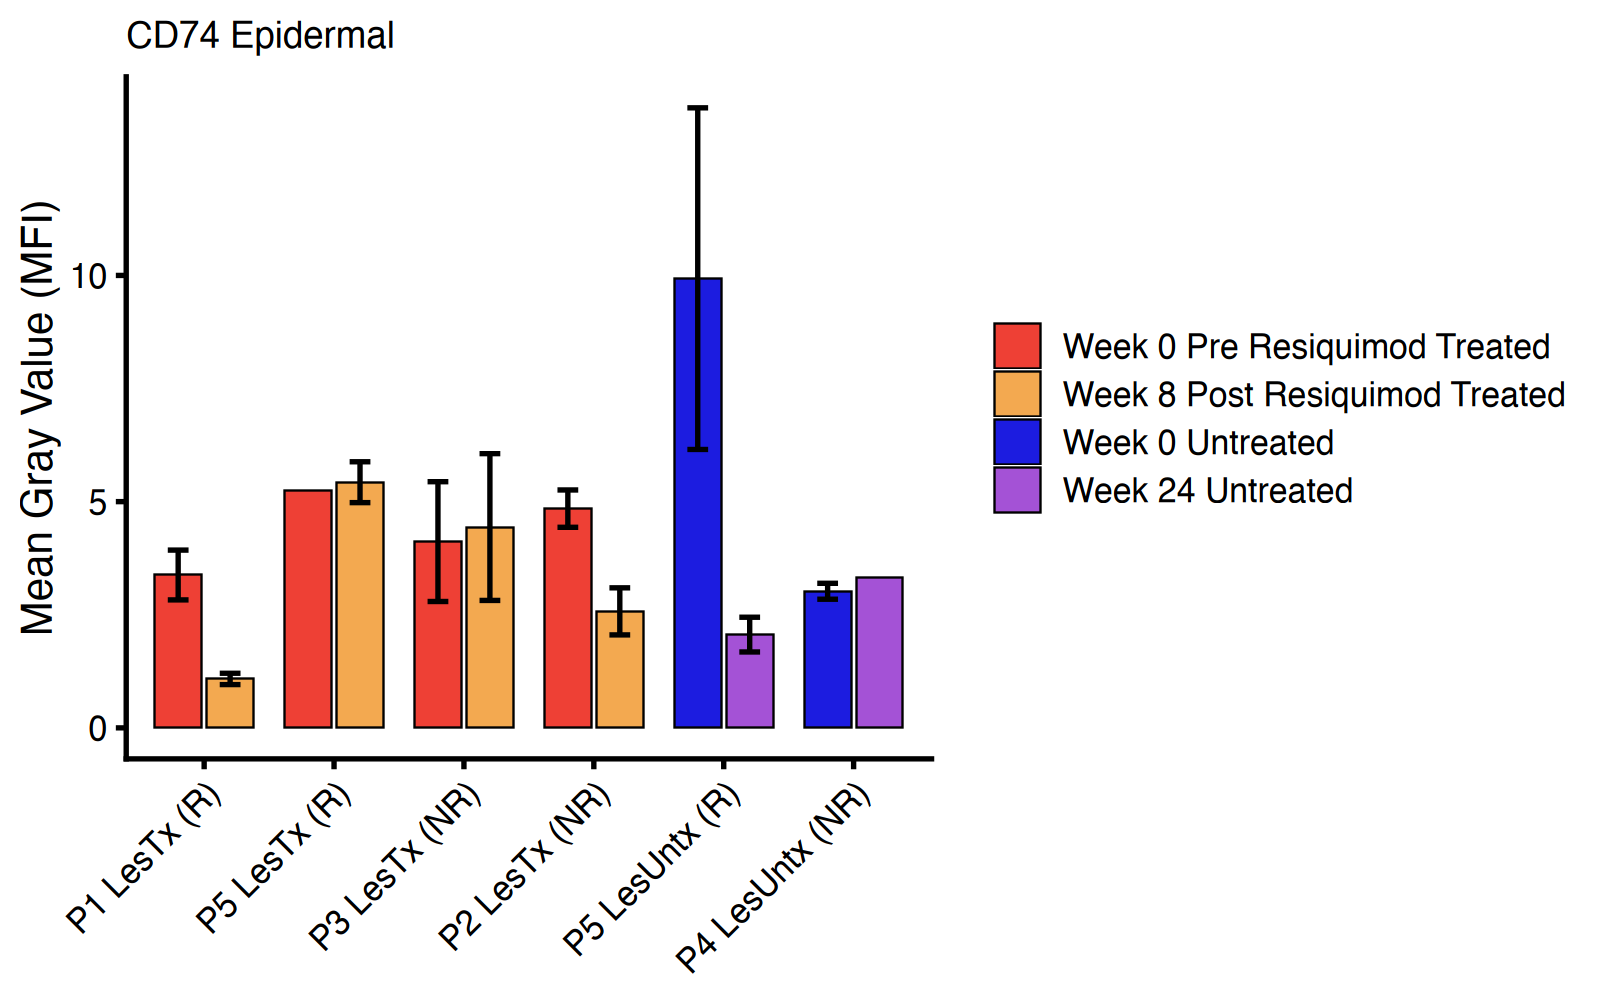

In [83]:
plots[['CD74']]